# OLMo2 ProFLingo Reference Robustness

Compare ProFLingo `match_rate` across OLMo2 derivatives for each available reference fingerprint. In the project's robustness framing, each subplot estimates how the match rate changes as we move away from that reference model's position in the lineage.

In [10]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("default")

## Configuration

`REFERENCE_REPORTS` is the active set of comparable ProFLingo trajectory reports. `REFERENCE_TARGET_KEYS` tells the plots where each reference model itself lies on the x-axis.


In [11]:
CWD = Path.cwd().resolve()
REPO_ROOT = CWD.parent if CWD.name == "notebooks" else CWD
ARTIFACT_DIR = REPO_ROOT / "artifacts" / "verification"
IMAGE_DIR = REPO_ROOT / "images"


def save_figure(fig, filename: str) -> Path:
    IMAGE_DIR.mkdir(parents=True, exist_ok=True)
    path = IMAGE_DIR / filename
    fig.savefig(path, bbox_inches="tight", dpi=300)
    return path


REFERENCE_REPORTS = {
    "Base reference": ARTIFACT_DIR / "olmo2_base_proflingo_reference_trajectory.json",
    "SFT reference": ARTIFACT_DIR / "olmo2_sft_proflingo_reference_trajectory.json",
    "DPO reference": ARTIFACT_DIR / "olmo2_dpo_proflingo_reference_trajectory.json",
    "RLVR reference": ARTIFACT_DIR / "olmo2_rlvr1_proflingo_reference_trajectory.json",
    "Instruct reference": ARTIFACT_DIR / "olmo2_instruct_proflingo_reference_trajectory.json",
}

REFERENCE_TARGET_KEYS = {
    "Base reference": "base@main",
    "SFT reference": "sft@main",
    "DPO reference": "dpo@main",
    "RLVR reference": "rlvr1@main",
    "Instruct reference": "instruct@main",
}

ALL_REFERENCE_TARGET_KEYS = REFERENCE_TARGET_KEYS

MODEL_VERSION_ORDER = [
    ("base@main", "base"),
    ("sft@main", "SFT"),
    ("dpo@main", "DPO"),
    ("rlvr1@step_400", "RLVR 400"),
    ("rlvr1@step_800", "RLVR 800"),
    ("rlvr1@step_1200", "RLVR 1200"),
    ("rlvr1@step_1600", "RLVR 1600"),
    ("rlvr1@step_2000", "RLVR 2000"),
    ("rlvr1@step_2400", "RLVR 2400"),
    ("rlvr1@main", "RLVR main"),
    ("instruct@step_400", "Instruct 400"),
    ("instruct@step_800", "Instruct 800"),
    ("instruct@step_1200", "Instruct 1200"),
    ("instruct@step_1600", "Instruct 1600"),
    ("instruct@step_2000", "Instruct 2000"),
    ("instruct@step_2400", "Instruct 2400"),
    ("instruct@main", "Instruct Main"),
]

## Load Reports

The parser only depends on the `proflingo[target_key].match_rate` summary and the shared target keys above, so adding another normalized reference report should require changing only `REFERENCE_REPORTS`.

In [12]:
def load_json(path: Path) -> dict:
    with path.open() as f:
        return json.load(f)


def extract_proflingo_match_rates(reference_name: str, path: Path) -> list[dict]:
    report = load_json(path)
    proflingo = report.get("proflingo") or {}
    rows = []
    for order, (target_key, model_version) in enumerate(MODEL_VERSION_ORDER):
        result = proflingo.get(target_key) or {}
        rows.append(
            {
                "reference": reference_name,
                "reference_model": report.get("reference_model"),
                "report_path": str(path),
                "target_key": target_key,
                "model_version": model_version,
                "order": order,
                "matched": result.get("matched"),
                "total": result.get("total"),
                "match_rate": result.get("match_rate"),
                "is_reference_target": target_key == ALL_REFERENCE_TARGET_KEYS.get(reference_name),
            }
        )
    return rows


rows = []
missing_reports = []
for reference_name, report_path in REFERENCE_REPORTS.items():
    if report_path.exists():
        rows.extend(extract_proflingo_match_rates(reference_name, report_path))
    else:
        missing_reports.append(report_path)

match_df = pd.DataFrame(rows)

if missing_reports:
    print("Missing reports:")
    for report_path in missing_reports:
        print(f"- {report_path}")

print(f"Loaded {match_df['reference'].nunique()} reference reports")
print(f"Rows: {len(match_df)}")
match_df.head()

Loaded 5 reference reports
Rows: 85


,reference,reference_model,report_path,target_key,model_version,order,matched,total,match_rate,is_reference_target
0,Base reference,allenai/OLMo-2-0425-1B,/home/azureuser/robust-auditing/artifacts/veri...,base@main,base,0,50,50,1.00,True
1,Base reference,allenai/OLMo-2-0425-1B,/home/azureuser/robust-auditing/artifacts/veri...,sft@main,SFT,1,0,50,0.00,False
2,Base reference,allenai/OLMo-2-0425-1B,/home/azureuser/robust-auditing/artifacts/veri...,dpo@main,DPO,2,1,50,0.02,False
3,Base reference,allenai/OLMo-2-0425-1B,/home/azureuser/robust-auditing/artifacts/veri...,rlvr1@step_400,RLVR 400,3,2,50,0.04,False
4,Base reference,allenai/OLMo-2-0425-1B,/home/azureuser/robust-auditing/artifacts/veri...,rlvr1@step_800,RLVR 800,4,1,50,0.02,False


## Robustness Plots

Each subplot marks the reference model's own x-axis position with a dashed vertical line and a larger diamond marker. That makes it easier to read the left/right falloff as the lineage moves away from the reference.

/tmp/ipykernel_6982/3039832941.py:62: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="lower right")
/tmp/ipykernel_6982/3039832941.py:62: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="lower right")
/tmp/ipykernel_6982/3039832941.py:62: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="lower right")
/tmp/ipykernel_6982/3039832941.py:62: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="lower right")
/tmp/ipykernel_6982/3039832941.py:62: UserWa

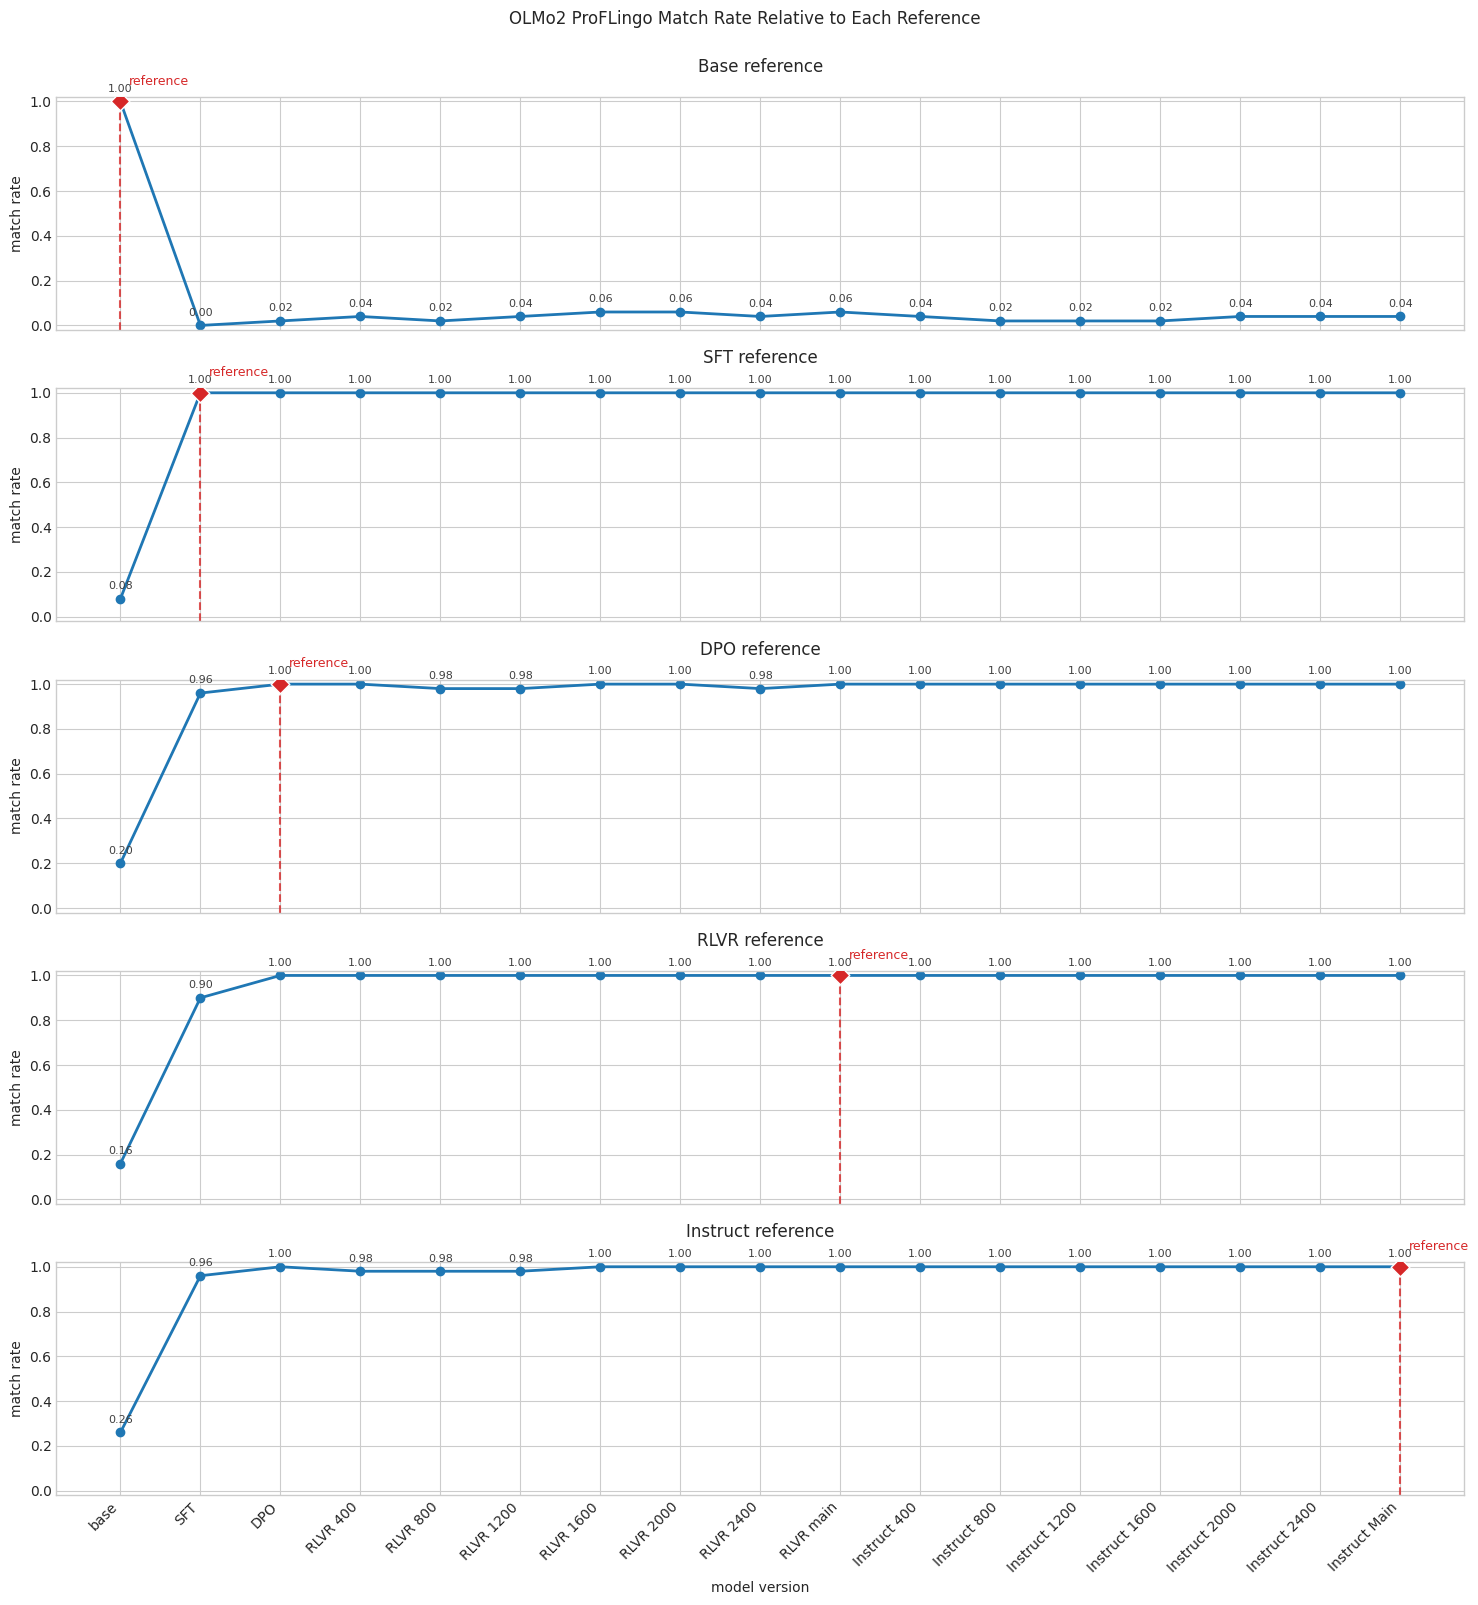

In [13]:
reference_names = list(REFERENCE_REPORTS)
fig, axes = plt.subplots(
    nrows=len(reference_names),
    ncols=1,
    figsize=(15, max(3.2 * len(reference_names), 6)),
    sharex=True,
    sharey=True,
)
if len(reference_names) == 1:
    axes = [axes]

x_labels = [label for _, label in MODEL_VERSION_ORDER]
for ax, reference_name in zip(axes, reference_names):
    group = match_df[match_df["reference"] == reference_name].sort_values("order")
    ax.plot(
        group["order"],
        group["match_rate"],
        marker="o",
        linewidth=2,
        color="tab:blue",
    )
    for _, point in group.iterrows():
        if pd.notna(point["match_rate"]):
            ax.annotate(
                f"{point['match_rate']:.2f}",
                xy=(point["order"], point["match_rate"]),
                xytext=(0, 7),
                textcoords="offset points",
                ha="center",
                fontsize=8,
                color="0.25",
            )

    reference_point = group[group["is_reference_target"]]
    if not reference_point.empty:
        ref_row = reference_point.iloc[0]
        ax.axvline(ref_row["order"], color="tab:red", linestyle="--", linewidth=1.5, alpha=0.8)
        ax.scatter(
            [ref_row["order"]],
            [ref_row["match_rate"]],
            marker="D",
            s=90,
            color="tab:red",
            edgecolor="white",
            linewidth=1,
            zorder=4,
        )
        ax.annotate(
            "reference",
            xy=(ref_row["order"], ref_row["match_rate"]),
            xytext=(6, 12),
            textcoords="offset points",
            color="tab:red",
            fontsize=9,
        )
    else:
        ax.text(0.01, 0.92, "reference position not configured", transform=ax.transAxes, color="tab:red")

    ax.set_title(reference_name, pad=18)
    ax.set_ylabel("match rate")
    ax.set_ylim(-0.02, 1.02)
    ax.legend(loc="lower right")

axes[-1].set_xlabel("model version")
axes[-1].set_xticks(range(len(MODEL_VERSION_ORDER)), x_labels, rotation=45, ha="right")
fig.suptitle("OLMo2 ProFLingo Match Rate Relative to Each Reference", y=1.0)
fig.tight_layout()
save_figure(fig, "proflingo_reference_match_rates.png")
plt.show()

## Main-Checkpoint Training-Distance Plots

These plots collapse the lineage to the five main checkpoints. Each x-axis tick shows the target model and the signed number of training examples between that target and the reference model. Edge labels show the fine-tuning step between adjacent checkpoints, with arrows pointing away from the reference.


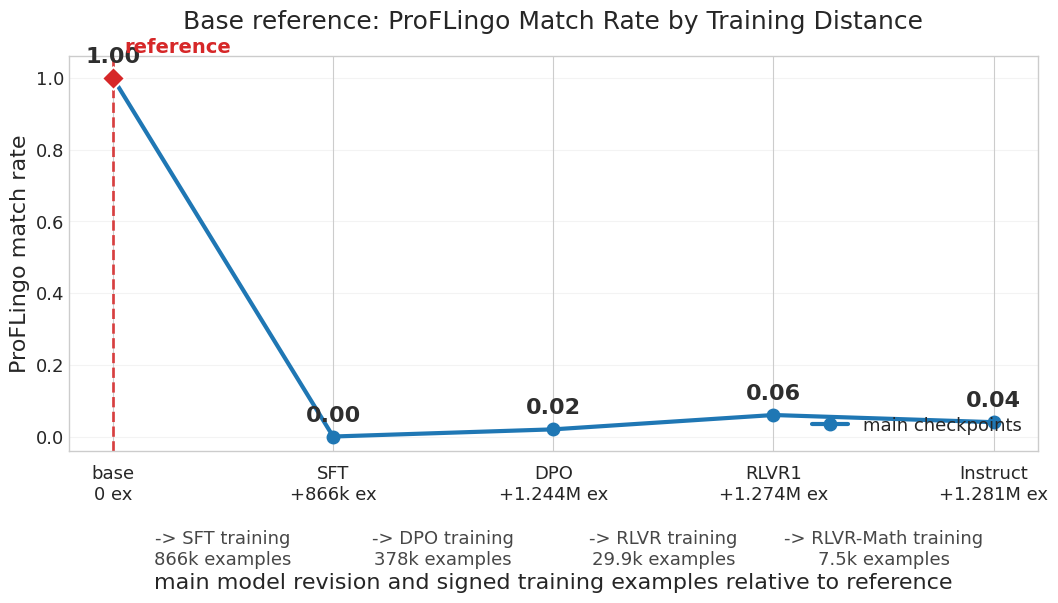

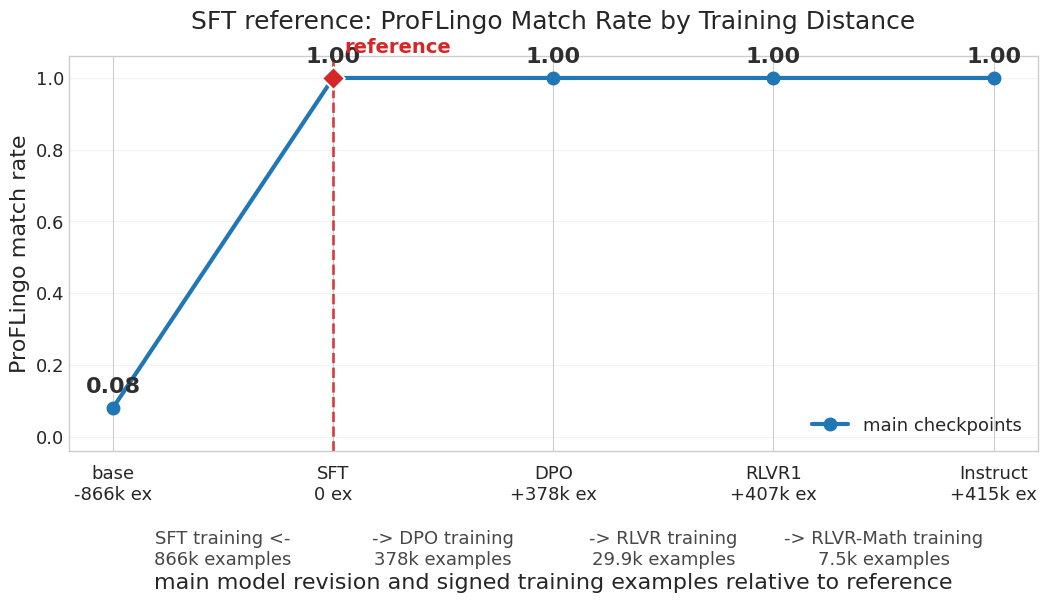

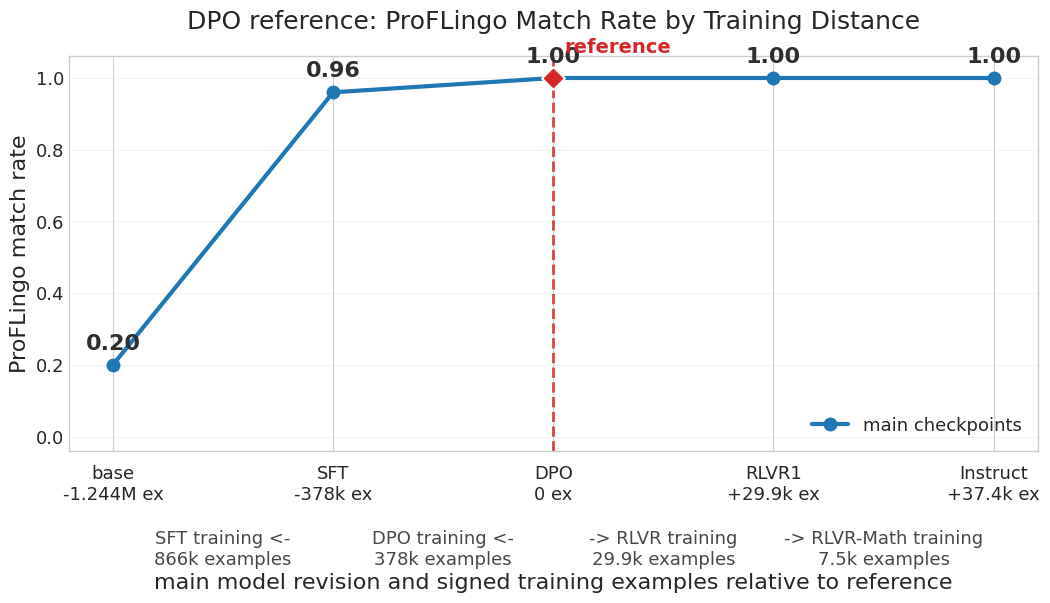

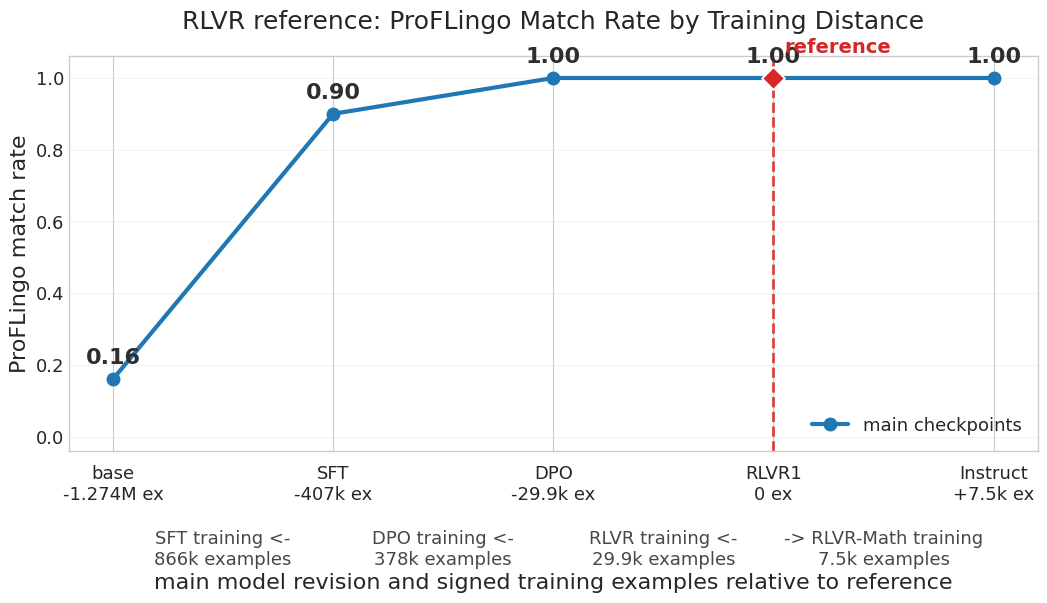

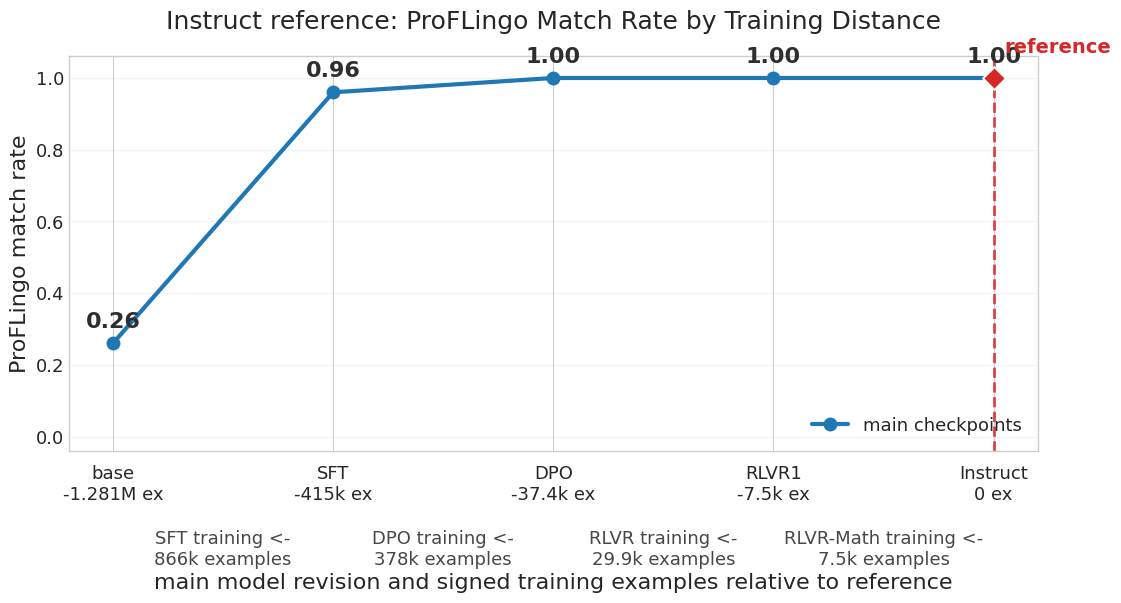

[PosixPath('/home/azureuser/robust-auditing/images/proflingo_base_robustness.png'),
 PosixPath('/home/azureuser/robust-auditing/images/proflingo_sft_robustness.png'),
 PosixPath('/home/azureuser/robust-auditing/images/proflingo_dpo_robustness.png'),
 PosixPath('/home/azureuser/robust-auditing/images/proflingo_rlvr1_robustness.png'),
 PosixPath('/home/azureuser/robust-auditing/images/proflingo_instruct_robustness.png')]

In [14]:
MAIN_MODEL_VERSION_ORDER = [
    ("base@main", "base"),
    ("sft@main", "SFT"),
    ("dpo@main", "DPO"),
    ("rlvr1@main", "RLVR1"),
    ("instruct@main", "Instruct"),
]

TRAINING_EDGES = [
    {
        "left": "base@main",
        "right": "sft@main",
        "technique": "SFT training",
        "examples": 866_000,
        "label": "866k examples",
    },
    {
        "left": "sft@main",
        "right": "dpo@main",
        "technique": "DPO training",
        "examples": 378_000,
        "label": "378k examples",
    },
    {
        "left": "dpo@main",
        "right": "rlvr1@main",
        "technique": "RLVR training",
        "examples": 29_900,
        "label": "29.9k examples",
    },
    {
        "left": "rlvr1@main",
        "right": "instruct@main",
        "technique": "RLVR-Math training",
        "examples": 7_500,
        "label": "7.5k examples",
    },
]

MAIN_TARGET_TO_ORDER = {
    target_key: order for order, (target_key, _) in enumerate(MAIN_MODEL_VERSION_ORDER)
}

cumulative_examples = {MAIN_MODEL_VERSION_ORDER[0][0]: 0}
for edge in TRAINING_EDGES:
    cumulative_examples[edge["right"]] = cumulative_examples[edge["left"]] + edge["examples"]


def format_examples(value: int) -> str:
    absolute = abs(value)
    if absolute == 0:
        return "0"
    sign = "+" if value > 0 else "-"
    if absolute >= 1_000_000:
        formatted = f"{absolute / 1_000_000:.3f}".rstrip("0").rstrip(".")
        return f"{sign}{formatted}M"
    if absolute >= 100_000:
        return f"{sign}{absolute // 1_000}k"
    if absolute % 1_000 == 0:
        return f"{sign}{absolute // 1_000}k"
    formatted = f"{absolute / 1_000:.1f}".rstrip("0").rstrip(".")
    return f"{sign}{formatted}k"


def main_checkpoint_tick_labels(reference_name: str) -> list[str]:
    reference_key = ALL_REFERENCE_TARGET_KEYS[reference_name]
    reference_examples = cumulative_examples[reference_key]
    labels = []
    for target_key, model_label in MAIN_MODEL_VERSION_ORDER:
        relative_examples = cumulative_examples[target_key] - reference_examples
        labels.append(f"{model_label}\n{format_examples(relative_examples)} ex")
    return labels


main_df = match_df[match_df["target_key"].isin(MAIN_TARGET_TO_ORDER)].copy()
main_df["main_order"] = main_df["target_key"].map(MAIN_TARGET_TO_ORDER)

REFERENCE_OUTPUT_FILENAMES = {
    "Base reference": "proflingo_base_robustness.png",
    "SFT reference": "proflingo_sft_robustness.png",
    "DPO reference": "proflingo_dpo_robustness.png",
    "RLVR reference": "proflingo_rlvr1_robustness.png",
    "Instruct reference": "proflingo_instruct_robustness.png",
}

ROBUSTNESS_FONT_CONFIG = {
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
}
SCORE_LABEL_FONT_SIZE = 16
EDGE_LABEL_FONT_SIZE = 13
REFERENCE_LABEL_FONT_SIZE = 14

reference_names = list(REFERENCE_REPORTS)
saved_robustness_figures = []

with plt.rc_context(ROBUSTNESS_FONT_CONFIG):
    for reference_name in reference_names:
        group = main_df[main_df["reference"] == reference_name].sort_values("main_order")
        reference_key = ALL_REFERENCE_TARGET_KEYS[reference_name]
        reference_order = MAIN_TARGET_TO_ORDER[reference_key]

        fig, ax = plt.subplots(figsize=(12.5, 6.8))
        ax.plot(
            group["main_order"],
            group["match_rate"],
            marker="o",
            markersize=9,
            linewidth=3,
            color="tab:blue",
            label="main checkpoints",
        )
        for _, point in group.iterrows():
            if pd.notna(point["match_rate"]):
                ax.annotate(
                    f"{point['match_rate']:.2f}",
                    xy=(point["main_order"], point["match_rate"]),
                    xytext=(0, 11),
                    textcoords="offset points",
                    ha="center",
                    fontsize=SCORE_LABEL_FONT_SIZE,
                    fontweight="bold",
                    color="0.18",
                )

        reference_point = group[group["target_key"] == reference_key]
        if not reference_point.empty:
            ref_row = reference_point.iloc[0]
            ax.axvline(reference_order, color="tab:red", linestyle="--", linewidth=2, alpha=0.85)
            ax.scatter(
                [reference_order],
                [ref_row["match_rate"]],
                marker="D",
                s=135,
                color="tab:red",
                edgecolor="white",
                linewidth=1.4,
                zorder=4,
            )
            ax.annotate(
                "reference",
                xy=(reference_order, ref_row["match_rate"]),
                xytext=(8, 18),
                textcoords="offset points",
                color="tab:red",
                fontsize=REFERENCE_LABEL_FONT_SIZE,
                fontweight="bold",
            )

        for edge in TRAINING_EDGES:
            left_order = MAIN_TARGET_TO_ORDER[edge["left"]]
            right_order = MAIN_TARGET_TO_ORDER[edge["right"]]
            midpoint = (left_order + right_order) / 2
            if right_order <= reference_order:
                edge_label = f"{edge['technique']} <-\n{edge['label']}"
            else:
                edge_label = f"-> {edge['technique']}\n{edge['label']}"
            ax.text(
                midpoint,
                -0.20,
                edge_label,
                transform=ax.get_xaxis_transform(),
                ha="center",
                va="top",
                fontsize=EDGE_LABEL_FONT_SIZE,
                color="0.28",
                clip_on=False,
            )

        ax.set_title(f"{reference_name}: ProFLingo Match Rate by Training Distance", pad=20)
        ax.set_ylabel("ProFLingo match rate")
        ax.set_xlabel("main model revision and signed training examples relative to reference", labelpad=50)
        ax.set_ylim(-0.04, 1.06)
        ax.set_xticks(
            range(len(MAIN_MODEL_VERSION_ORDER)),
            main_checkpoint_tick_labels(reference_name),
        )
        ax.tick_params(axis="x", pad=10)
        ax.grid(axis="y", alpha=0.22)
        ax.legend(loc="lower right", frameon=False)

        fig.subplots_adjust(bottom=0.30, top=0.88)
        output_filename = REFERENCE_OUTPUT_FILENAMES[reference_name]
        saved_robustness_figures.append(save_figure(fig, output_filename))
        plt.show()

saved_robustness_figures

## Match-Rate Table

In [15]:
pivot = (
    match_df.pivot(index="model_version", columns="reference", values="match_rate")
    .reindex([label for _, label in MODEL_VERSION_ORDER])
)
pivot

reference,Base reference,DPO reference,Instruct reference,RLVR reference,SFT reference
model_version,,,,,
base,1.00,0.20,0.26,0.16,0.08
SFT,0.00,0.96,0.96,0.90,1.00
DPO,0.02,1.00,1.00,1.00,1.00
RLVR 400,0.04,1.00,0.98,1.00,1.00
RLVR 800,0.02,0.98,0.98,1.00,1.00
RLVR 1200,0.04,0.98,0.98,1.00,1.00
RLVR 1600,0.06,1.00,1.00,1.00,1.00
RLVR 2000,0.06,1.00,1.00,1.00,1.00
RLVR 2400,0.04,0.98,1.00,1.00,1.00


## Instruct Reference: Five Checkpoints Plus Fine-Tuned Adapter

Extend the Instruct-reference ProFLingo match-rate graph from the five key OLMo2 checkpoints to the new `grpo_10k_ft` fine-tuned adapter. The Instruct checkpoint is marked as the reference model.


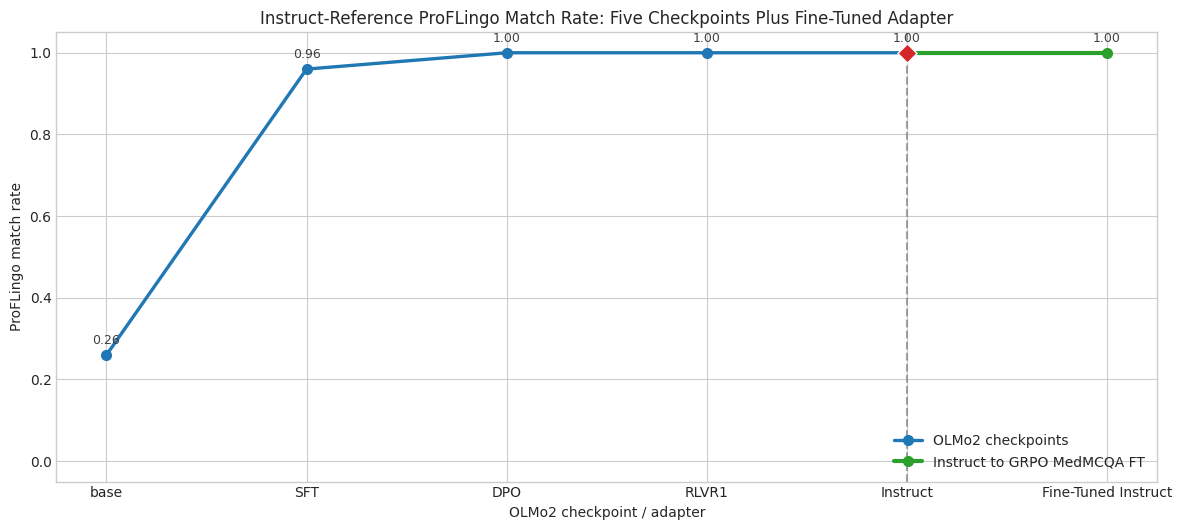

,model_version,matched,total,match_rate,is_reference_target
0,base,13,50,0.26,False
1,SFT,48,50,0.96,False
2,DPO,50,50,1.00,False
3,RLVR1,50,50,1.00,False
4,Instruct,50,50,1.00,True
5,GRPO MedMCQA\nFine-Tune,50,50,1.00,False


In [16]:
ADAPTER_RUN_ID = "grpo_10k_ft_leftpad"
ADAPTER_PROFLINGO_REPORT = REPO_ROOT / "artifacts" / "adapter_evals" / ADAPTER_RUN_ID / "proflingo" / "report.json"

instruct_reference_name = "Instruct reference"
instruct_reference_key = REFERENCE_TARGET_KEYS[instruct_reference_name]
instruct_report = load_json(REFERENCE_REPORTS[instruct_reference_name])
instruct_proflingo = instruct_report.get("proflingo") or {}

five_checkpoint_df = pd.DataFrame(
    [
        {
            "target_key": target_key,
            "model_version": model_label,
            "order": order,
            "match_rate": instruct_proflingo.get(target_key, {}).get("match_rate"),
            "matched": instruct_proflingo.get(target_key, {}).get("matched"),
            "total": instruct_proflingo.get(target_key, {}).get("total"),
            "is_reference_target": target_key == instruct_reference_key,
        }
        for order, (target_key, model_label) in enumerate(MAIN_MODEL_VERSION_ORDER)
    ]
)

adapter_proflingo = load_json(ADAPTER_PROFLINGO_REPORT)
adapter_row = {
    "target_key": f"{ADAPTER_RUN_ID}@adapter",
    "model_version": "GRPO MedMCQA\nFine-Tune",
    "order": len(MAIN_MODEL_VERSION_ORDER),
    "match_rate": adapter_proflingo.get("match_rate"),
    "matched": adapter_proflingo.get("matched"),
    "total": adapter_proflingo.get("total"),
    "is_reference_target": False,
}
extended_match_df = pd.concat(
    [five_checkpoint_df, pd.DataFrame([adapter_row])],
    ignore_index=True,
).sort_values("order")

fig, ax = plt.subplots(figsize=(12, 5.4))
lineage_segment = extended_match_df[extended_match_df["order"] <= len(MAIN_MODEL_VERSION_ORDER) - 1]
ft_segment = extended_match_df[extended_match_df["order"] >= len(MAIN_MODEL_VERSION_ORDER) - 1]
ax.plot(
    lineage_segment["order"],
    lineage_segment["match_rate"],
    marker="o",
    markersize=7,
    linewidth=2.4,
    color="tab:blue",
    label="OLMo2 checkpoints",
)
ax.plot(
    ft_segment["order"],
    ft_segment["match_rate"],
    marker="o",
    markersize=7,
    linewidth=3.0,
    color="tab:green",
    label="Instruct to GRPO MedMCQA FT",
)
for _, point in extended_match_df.iterrows():
    ax.annotate(
        f"{point['match_rate']:.2f}",
        xy=(point["order"], point["match_rate"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color="0.25",
    )

reference_point = extended_match_df[extended_match_df["is_reference_target"]].iloc[0]
ax.axvline(reference_point["order"], color="0.55", linestyle="--", linewidth=1.5, alpha=0.8)
ax.scatter(
    [reference_point["order"]],
    [reference_point["match_rate"]],
    marker="D",
    s=95,
    color="tab:red",
    edgecolor="white",
    linewidth=1,
    zorder=4,
)
x_ticks = list(range(len(MAIN_MODEL_VERSION_ORDER))) + [len(MAIN_MODEL_VERSION_ORDER)]
x_tick_labels = [label for _, label in MAIN_MODEL_VERSION_ORDER] + ["Fine-Tuned Instruct"]
ax.set_xticks(x_ticks, x_tick_labels)
ax.set_ylim(-0.05, 1.05)
ax.set_ylabel("ProFLingo match rate")
ax.set_xlabel("OLMo2 checkpoint / adapter")
ax.set_title("Instruct-Reference ProFLingo Match Rate: Five Checkpoints Plus Fine-Tuned Adapter")
ax.legend(loc="lower right")
fig.tight_layout()
save_figure(fig, "proflingo_clean_grpo_adapter_fingerprint.png")
plt.show()

display(extended_match_df[["model_version", "matched", "total", "match_rate", "is_reference_target"]])


## Instruct Reference: Exact-Chain Passing Adapter


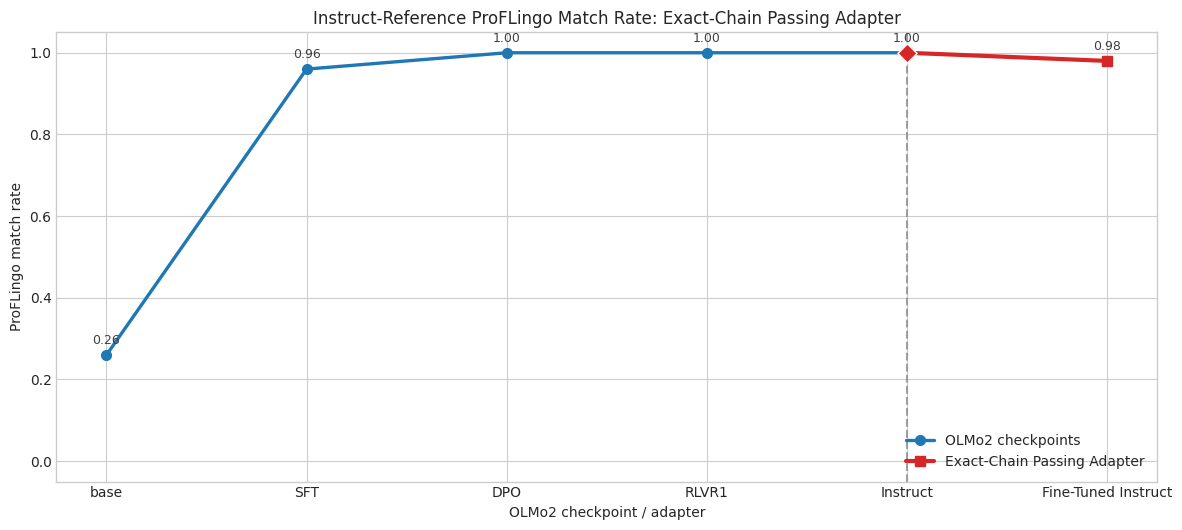

,model_version,matched,total,match_rate,is_reference_target
0,base,13,50,0.26,False
1,SFT,48,50,0.96,False
2,DPO,50,50,1.00,False
3,RLVR1,50,50,1.00,False
4,Instruct,50,50,1.00,True
5,Exact-Chain Passing Adapter,49,50,0.98,False


In [17]:
EXACT_CHAIN_ADAPTER_RUN_ID = "passed_harmmean_exact_chain_hhsamples_seed3"
EXACT_CHAIN_ADAPTER_PROFLINGO_REPORT = (
    REPO_ROOT / "artifacts" / "adapter_evals" / EXACT_CHAIN_ADAPTER_RUN_ID / "proflingo" / "report.json"
)

exact_chain_proflingo = load_json(EXACT_CHAIN_ADAPTER_PROFLINGO_REPORT)
exact_chain_row = {
    "target_key": f"{EXACT_CHAIN_ADAPTER_RUN_ID}@adapter",
    "model_version": "Exact-Chain Passing Adapter",
    "order": len(MAIN_MODEL_VERSION_ORDER),
    "match_rate": exact_chain_proflingo.get("match_rate"),
    "matched": exact_chain_proflingo.get("matched"),
    "total": exact_chain_proflingo.get("total"),
    "is_reference_target": False,
}
exact_chain_match_df = pd.concat(
    [five_checkpoint_df, pd.DataFrame([exact_chain_row])],
    ignore_index=True,
).sort_values("order")

fig, ax = plt.subplots(figsize=(12, 5.4))
lineage_segment = exact_chain_match_df[exact_chain_match_df["order"] <= len(MAIN_MODEL_VERSION_ORDER) - 1]
ft_segment = exact_chain_match_df[exact_chain_match_df["order"] >= len(MAIN_MODEL_VERSION_ORDER) - 1]
ax.plot(
    lineage_segment["order"],
    lineage_segment["match_rate"],
    marker="o",
    markersize=7,
    linewidth=2.4,
    color="tab:blue",
    label="OLMo2 checkpoints",
)
ax.plot(
    ft_segment["order"],
    ft_segment["match_rate"],
    marker="s",
    markersize=7,
    linewidth=3.0,
    color="tab:red",
    label="Exact-Chain Passing Adapter",
)
for _, point in exact_chain_match_df.iterrows():
    ax.annotate(
        f"{point['match_rate']:.2f}",
        xy=(point["order"], point["match_rate"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color="0.25",
    )

reference_point = exact_chain_match_df[exact_chain_match_df["is_reference_target"]].iloc[0]
ax.axvline(reference_point["order"], color="0.55", linestyle="--", linewidth=1.5, alpha=0.8)
ax.scatter(
    [reference_point["order"]],
    [reference_point["match_rate"]],
    marker="D",
    s=95,
    color="tab:red",
    edgecolor="white",
    linewidth=1,
    zorder=4,
)
x_ticks = list(range(len(MAIN_MODEL_VERSION_ORDER))) + [len(MAIN_MODEL_VERSION_ORDER)]
x_tick_labels = [label for _, label in MAIN_MODEL_VERSION_ORDER] + ["Fine-Tuned Instruct"]
ax.set_xticks(x_ticks, x_tick_labels)
ax.set_ylim(-0.05, 1.05)
ax.set_ylabel("ProFLingo match rate")
ax.set_xlabel("OLMo2 checkpoint / adapter")
ax.set_title("Instruct-Reference ProFLingo Match Rate: Exact-Chain Passing Adapter")
ax.legend(loc="lower right")
fig.tight_layout()
save_figure(fig, "proflingo_exact_chain_adapter_fingerprint.png")
plt.show()

display(exact_chain_match_df[["model_version", "matched", "total", "match_rate", "is_reference_target"]])


## Instruct Reference: Clean GRPO and Exact-Chain Passing Adapter

Overlay the clean GRPO and exact-chain passing adapter branches on one Instruct-reference ProFLingo graph.


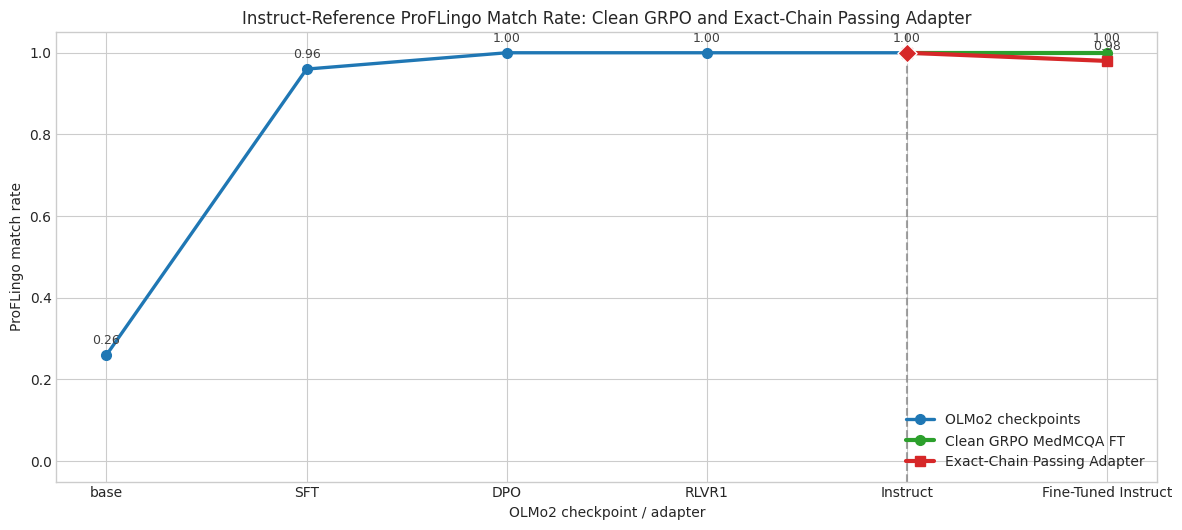

,model_version,matched,total,match_rate,is_reference_target
0,base,13,50,0.26,False
1,SFT,48,50,0.96,False
2,DPO,50,50,1.00,False
3,RLVR1,50,50,1.00,False
4,Instruct,50,50,1.00,True
5,GRPO MedMCQA Fine-Tune,50,50,1.00,False
6,Exact-Chain Passing Adapter,49,50,0.98,False


In [18]:
combined_adapter_rows = [
    {
        "target_key": f"{ADAPTER_RUN_ID}@adapter",
        "model_version": "GRPO MedMCQA Fine-Tune",
        "plot_label": "Clean GRPO MedMCQA FT",
        "color": "tab:green",
        "marker": "o",
        "report": adapter_proflingo,
    },
    {
        "target_key": f"{EXACT_CHAIN_ADAPTER_RUN_ID}@adapter",
        "model_version": "Exact-Chain Passing Adapter",
        "plot_label": "Exact-Chain Passing Adapter",
        "color": "tab:red",
        "marker": "s",
        "report": exact_chain_proflingo,
    },
]
for adapter_row in combined_adapter_rows:
    report = adapter_row.pop("report")
    adapter_row.update(
        {
            "order": len(MAIN_MODEL_VERSION_ORDER),
            "match_rate": report.get("match_rate"),
            "matched": report.get("matched"),
            "total": report.get("total"),
            "is_reference_target": False,
        }
    )

combined_match_df = pd.concat(
    [five_checkpoint_df, pd.DataFrame(combined_adapter_rows)],
    ignore_index=True,
).sort_values(["order", "target_key"])

fig, ax = plt.subplots(figsize=(12, 5.4))
lineage_segment = combined_match_df[combined_match_df["order"] <= len(MAIN_MODEL_VERSION_ORDER) - 1]
ax.plot(
    lineage_segment["order"],
    lineage_segment["match_rate"],
    marker="o",
    markersize=7,
    linewidth=2.4,
    color="tab:blue",
    label="OLMo2 checkpoints",
)

instruct_row = combined_match_df[combined_match_df["target_key"] == "instruct@main"].iloc[0].to_dict()
for adapter_row in combined_adapter_rows:
    ft_segment = pd.DataFrame([instruct_row, adapter_row])
    ax.plot(
        ft_segment["order"],
        ft_segment["match_rate"],
        marker=adapter_row["marker"],
        markersize=7,
        linewidth=3.0,
        color=adapter_row["color"],
        label=adapter_row["plot_label"],
    )

for _, point in combined_match_df.iterrows():
    ax.annotate(
        f"{point['match_rate']:.2f}",
        xy=(point["order"], point["match_rate"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color="0.25",
    )

reference_point = combined_match_df[combined_match_df["is_reference_target"]].iloc[0]
ax.axvline(reference_point["order"], color="0.55", linestyle="--", linewidth=1.5, alpha=0.8)
ax.scatter(
    [reference_point["order"]],
    [reference_point["match_rate"]],
    marker="D",
    s=95,
    color="tab:red",
    edgecolor="white",
    linewidth=1,
    zorder=4,
)
x_ticks = list(range(len(MAIN_MODEL_VERSION_ORDER))) + [len(MAIN_MODEL_VERSION_ORDER)]
x_tick_labels = [label for _, label in MAIN_MODEL_VERSION_ORDER] + ["Fine-Tuned Instruct"]
ax.set_xticks(x_ticks, x_tick_labels)
ax.set_ylim(-0.05, 1.05)
ax.set_ylabel("ProFLingo match rate")
ax.set_xlabel("OLMo2 checkpoint / adapter")
ax.set_title("Instruct-Reference ProFLingo Match Rate: Clean GRPO and Exact-Chain Passing Adapter")
ax.legend(loc="lower right")
fig.tight_layout()
save_figure(fig, "proflingo_ft_fingerprint_comparison.png")
plt.show()

display(combined_match_df[["model_version", "matched", "total", "match_rate", "is_reference_target"]])
